In [1]:
from collections import defaultdict

import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.spatial as scspatial
from desmin_reconstruction.plotting.lineplots import line_and_bandplot
from desmin_reconstruction.preprocessing.bbox import BoundingSquare, filter_bounded
from desmin_reconstruction.utils.array import midpoints
from desmin_reconstruction.utils.math import n_sphere_surface_area
from tqdm import tqdm


COLOR_DICT = {
    "desmin": "#FF0000",
    "actinin": "#00FF00",
    "actin": cc.cm.glasbey_light(62),
}
LABEL_DICT = {"desmin": "Desmin", "actin": "Actin", "actinin": "α-actinin"}
scatter_kwargs = {"alpha": 0.3, "s": 0.2}

df = pl.read_csv("../data/results/desmin_alphaactinin_600nm_aligned.csv")
out = df.partition_by("probe")

In [2]:
points = {
    name: out[i].select(["x", "y", "z"]).to_numpy()
    for i, name in enumerate(("desmin", "actinin"))
}
points["desmin"].shape


(59957, 3)

In [3]:
x0s = (2, 6, 10, 14, 18, 1, 5, 9, 13, 17, 0, 4, 8, 12, 16, 15)
y0s = (9, 9, 9, 9, 9, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, -3)
bboxes = [BoundingSquare(x0, y0, side=4) for x0, y0 in zip(x0s, y0s)]

In [4]:
bbox = bboxes[4]
sq1 = {k: filter_bounded(v, bbox) for k, v in points.items()}


In [5]:
def point_point_correlation(
    points_1, points_2, r_max: float, dr: float, volume: float = 1.0
):
    n1, n2 = len(points_1), len(points_2)
    r_bins = np.arange(0, r_max + dr, dr)

    dist_mat = scspatial.KDTree(points_1).sparse_distance_matrix(
        scspatial.KDTree(points_2), max_distance=r_max, output_type="coo_matrix"
    )
    dist_counts = np.histogram(dist_mat.data, r_bins)[0]
    r = midpoints(r_bins)
    coeff = volume / (n1 * n2 * dr)
    return r, coeff * dist_counts / n_sphere_surface_area(points_1.shape[1], r)


def point_set_correlation(
    points_1, points_set, r_max: float, dr: float, volume: float = 1.0
):
    n1, n2 = len(points_1), len(points_set)
    r_bins = np.arange(0, r_max + dr, dr)

    dists = scspatial.KDTree(points_set).query(points_1)[0]
    print(np.mean(dists))
    dist_counts = np.histogram(dists, r_bins)[0]
    r = midpoints(r_bins)
    coeff = 1 / n1  # volume / (n1 * dr)
    return r, coeff * dist_counts  # / n_sphere_surface_area(points_1.shape[1], r)

In [6]:
corrs = defaultdict(list)

for bbox in tqdm(bboxes):
    sq1 = {k: filter_bounded(v, bbox) for k, v in points.items()}
    r, corr = point_set_correlation(sq1["desmin"], sq1["actinin"], 1.0, 0.01, 16.0)
    corrs["actinin"].append(corr)


100%|██████████| 16/16 [00:00<00:00, 98.92it/s] 

0.22431605773929417
0.25692240888609014
0.26470191938136817
0.25592464602641085
0.30077843922410546
0.28738085705821276
0.25296547888002685
0.27158514785810295
0.27449189921823636
0.2855010200558353
0.12917167433780363
0.29528804129319136
0.27607291271577755
0.352152141473278
0.24417210724925809
0.294640607782038


In [7]:
np.max(sq1["desmin"][:, 2])

np.float64(0.9318932640078249)

In [8]:
df = pl.read_csv("../data/results/actin_desmin_600nm_aligned.csv")
out = df.partition_by("probe")

points_actin = {
    name: out[i].select(["x", "y", "z"]).to_numpy()
    for i, name in enumerate(("actin", "desmin"))
}

x0s = (3, 7, 7, 11, 11, 11, 11, 15, 15, 15, 19, 19)
y0s = (-2, -1.5, -5.5, -1, -5, -9, -13, -1, -5, -9, -2, -6)
bboxes_actin = [BoundingSquare(x0, y0, side=4) for x0, y0 in zip(x0s, y0s)]

for bbox in tqdm(bboxes_actin):
    sq1 = {k: filter_bounded(v, bbox) for k, v in points_actin.items()}
    r, corr = point_set_correlation(sq1["desmin"], sq1["actin"], 1.0, 0.01, 16.0)
    corrs["actin"].append(corr)


  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 117.95it/s]

0.08862076801103418
0.08624882270986019
0.09932153147593134
0.08279324797459128
0.12378260417249023
0.11079453717423533
0.08407999560109321
0.0738016061194201
0.128387892658003
0.13424476156045595
0.13603153411989935
0.0903679319488703


In [10]:
def internal_division_point(x1, x2, y1, y2):
    return (y1 * x2 + y2 * x1) / (y1 + y2)


def find_crossing_points(x, y1, y2):
    y_diff = y1 - y2
    x_exact_crossing = x[np.flatnonzero(y_diff == 0)]

    ind_sign_change = np.flatnonzero(y_diff[:-1] * y_diff[1:] <= 0)

    x_interped_crossing = internal_division_point(
        x[ind_sign_change],
        x[ind_sign_change + 1],
        y_diff[ind_sign_change],
        -y_diff[ind_sign_change + 1],
    )
    x_crossing = np.concatenate((x_exact_crossing, x_interped_crossing), axis=0)
    return np.sort(x_crossing), ind_sign_change

/tmp/ipykernel_557791/716518084.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"Median: {float(r_median):.1f}nm",


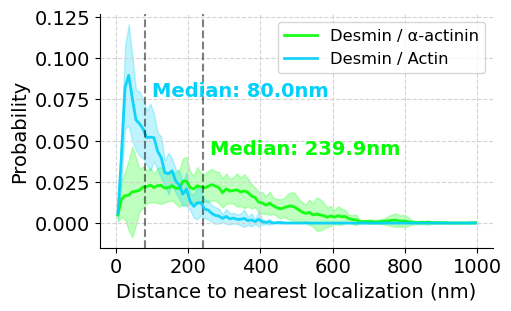

In [12]:
plt.rc("font", size=14)
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for protein, corr_data in corrs.items():
    counts = np.mean(corr_data, axis=0)
    ax = line_and_bandplot(
        ax,
        r * 1000,
        counts,
        np.std(corr_data, axis=0),
        color=COLOR_DICT[protein],
        label=f"Desmin / {LABEL_DICT[protein]}",
        linewidth=2.0,
        alpha=0.9,
        alpha_band=0.25,
    )
    r_median, idx_cross = find_crossing_points(r * 1000, np.cumsum(counts), 0.5)

    # r_avg = np.sum(r*counts)/np.sum(counts)*1000
    ax.axvline(r_median, ls="--", color="k", alpha=0.5)
    ax.text(
        r_median + 20,
        counts[idx_cross] + 0.02,
        f"Median: {float(r_median):.1f}nm",
        color=COLOR_DICT[protein],
        weight="bold",
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(ls="--", color="lightgray")
ax.set_xlabel("Distance to nearest localization (nm)")
ax.set_ylabel("Probability")
ax.legend(fontsize="small")
fig.savefig("../figures/fig_3/3c.svg", dpi=500, bbox_inches="tight")

In [ ]:
np.sum(r * corr) / np.sum(corr)

np.float64(0.0904337899543379)

In [ ]:
midpoint().arange(0, 2.0, 0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])